## The notebook provides preliminary evaluations for the spaceborne verion of the Concurrent Artificially-Intelligent Spectrometry and Adaptive Lidar System (CASALS).
The Level 1 requirements are derived from the NASA's Surface Topography and Vegetation Incubation Study Team Report June 2021 avalaible at https://science.nasa.gov/wp-content/uploads/2023/06/STV_Study_Report_20210622.pdf

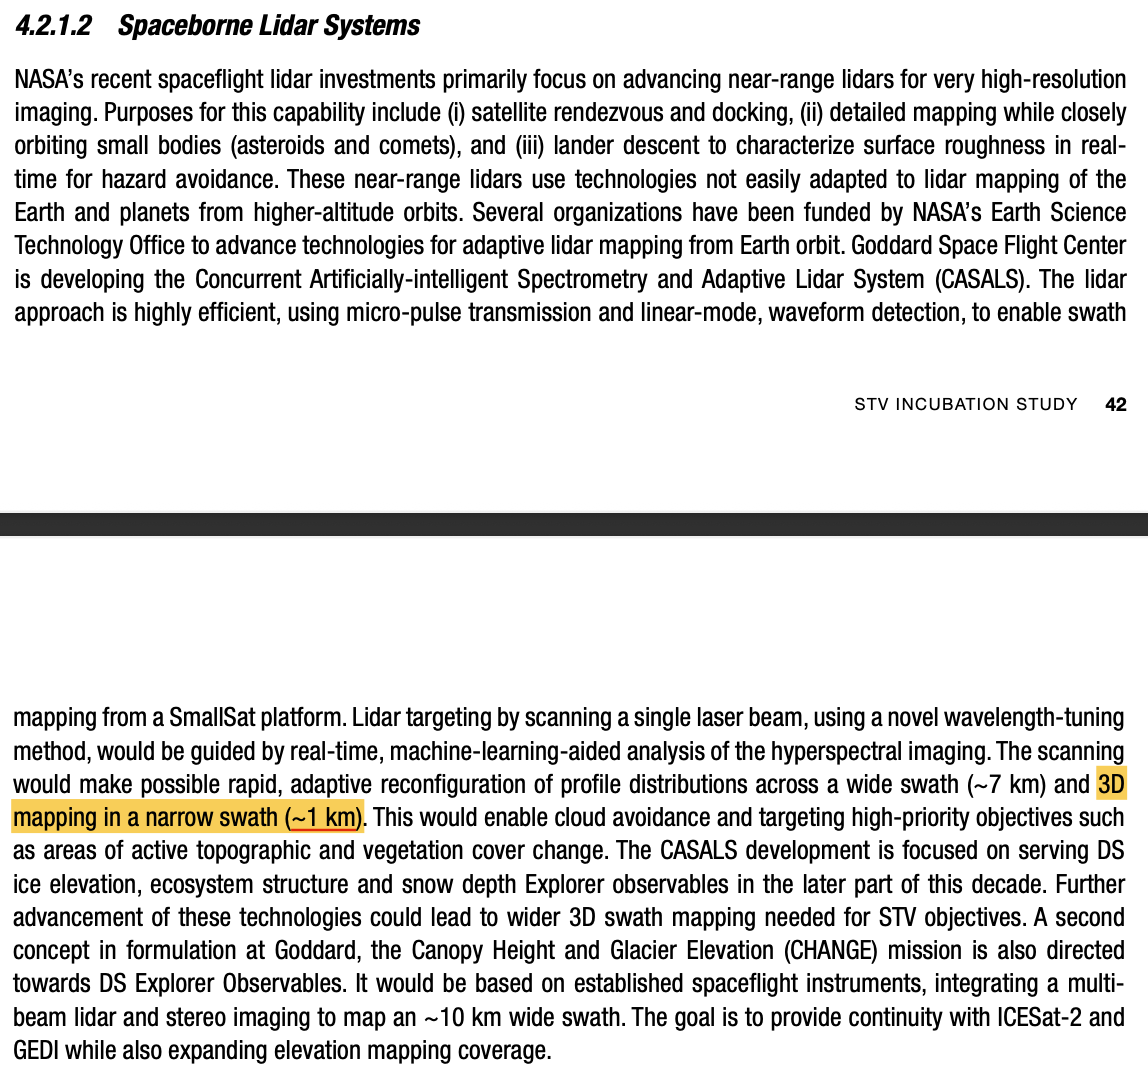

## CASALS Orbit Evaluation

#### NB1: 500 km Orbit Relative to Earth: 
###### -500km for Polar orbit allows polar ice mapping. 
###### -allows thrusters/propulsion to be turned off for longer period of time. 
#### NB2: 92˚ Inclination to cover the height of ice over poles (like ICESat-2)
#### Row 21: The useful information is that it takes ~5576 secs to complete an orbit around earth

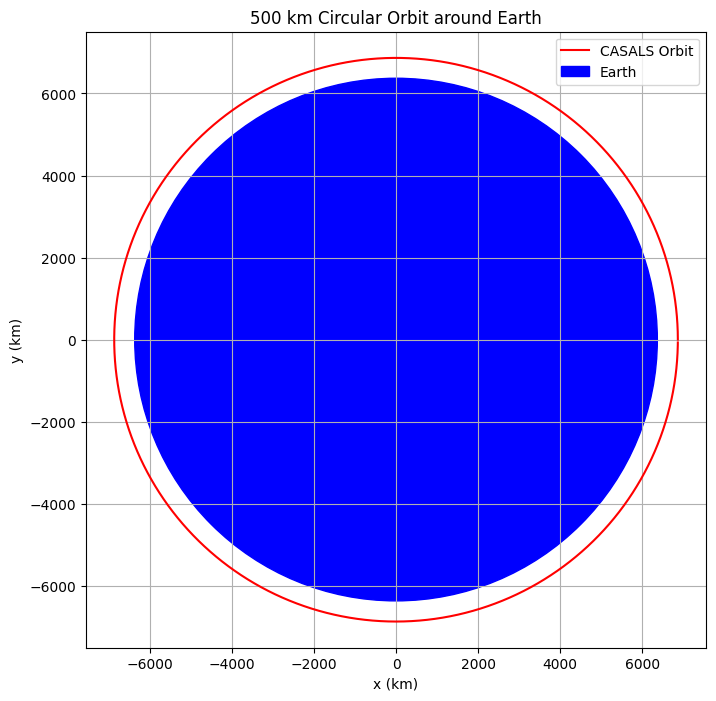

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
M_earth = 5.972e24     # kg
R_earth = 6371e3       # m
altitude = 500e3       # m
r_orbit = R_earth + altitude

# Initial position and velocity
r0 = np.array([r_orbit, 0])
v0 = np.array([0, np.sqrt(G * M_earth / r_orbit)])  # circular velocity

# Time settings
dt = 1  # seconds
num_steps = 5660  # ~1.57 hours, 94.33 min total simulated time for a full orbit

# Allocate arrays
r = np.zeros((num_steps, 2))
v = np.zeros((num_steps, 2))
r[0], v[0] = r0, v0

# Gravity function
def gravity(pos):
    r_mag = np.linalg.norm(pos)
    return -G * M_earth * pos / r_mag**3

# Integrate with Euler method
for i in range(num_steps - 1):
    a = gravity(r[i])
    v[i + 1] = v[i] + a * dt
    r[i + 1] = r[i] + v[i + 1] * dt

# Plotting
plt.figure(figsize=(8, 8))
plt.plot(r[:, 0] / 1e3, r[:, 1] / 1e3, color='red', label='CASALS Orbit')
earth = plt.Circle((0, 0), R_earth / 1e3, color='blue', label='Earth')
plt.gca().add_patch(earth)
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.title('500 km Circular Orbit around Earth')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

#### Calculate SC velocity on Ground

In [27]:
# Constants
G = 6.67430e-11  # m^3/kg/s^2
M_earth = 5.97219e24  # kg
R_earth = 6371e3  # m
altitude = 500e3  # m
c = 299792458  # speed of light in m/s

# Orbital radius
r = R_earth + altitude

# Circular orbital velocity 𝑣 = √𝐺𝑀/r
v = np.sqrt(G * M_earth / r)

# Relative velocity on earth, or Ground speed, ve = v*R_earth/r
ve = v*R_earth/r

# Print results
print(f"Circular orbital velocity at 500 km altitude: {v:.2f} m/s or {v/1e3:.2f} km/s")
print(f"Ground Speed:                                 {ve:.2f} m/s or {ve/1e3:.2f} km/s")

Circular orbital velocity at 500 km altitude: 7616.57 m/s or 7.62 km/s
Ground Speed:                                 7062.32 m/s or 7.06 km/s


#### With the ground velocity evaluated, we estimate the laser Rep Rate

##### Aircraft 32 * 8 = 256. Swaths on ground 167 for now. 
## We will get back to it.

In [28]:
ve=7062.32             #Ground speed if SC 
GSD=6                  #Ground Sample Distance in m, comes from the ability to determine slopes on ground. 
Swath_width=1000       #in m

# Calculate Rep Rate
Number_spot=Swath_width/GSD
RepRate=Number_spot*(ve/GSD)

# Print results
print(f" #Spots to cover 1km swath: {Number_spot:.0f}")
print(f" Rep Rate:                  {RepRate*1e-3:.3f} kHz")

 #Spots to cover 1km swath: 167
 Rep Rate:                  196.176 kHz


### Based on rep rate and laser power, let's eavlaute some parameters for the laser system
#### Note that the #spots (167) is greater than pixels on detector (64), there needs to be plan to sweep through scan to accomodate the swath points. Important to note that the optics / grating is not the bottleneck, but the detector is to necessiate the process

In [29]:
RepRate = 196176                   # Rep Rate
pulse_energy_J = 1.5e-4            # Energy per pulse in joules 150µJ

# calculate power output
Laser_output_power=RepRate*pulse_energy_J

# Pulse Peak Optical Power evaluated as = 150µJ/2ns
PeakPower=150e-6/2e-9

# calculate input power to laser assuming system efficiency of 15%
Laser_input_power=Laser_output_power*100/15

# calculate thermal dissipation from laser assuming system efficiency of 15%
Laser_thermal_dissipation=Laser_input_power-Laser_output_power

print(f" Laser Output Power: {Laser_output_power:.2f} W")
print(f" Peak Optical Power: {150e-6/2e-9/1e3:.2f} kW")
print(f" Laser Input Power:  {Laser_input_power:.2f} W")
print(f" Laser dissipation:  {Laser_thermal_dissipation:.2f} W")

 Laser Output Power: 29.43 W
 Peak Optical Power: 75.00 kW
 Laser Input Power:  196.18 W
 Laser dissipation:  166.75 W


#### Let's avaluate some more laser output characteristics parameters

In [30]:
# calculate laser duty cycle based on rep rate and pulse duration
Duty_cycle=100*RepRate*2e-9

# calculate gap between pulse
Pulse_time_with_gap=1/RepRate

# Calculate distances for the pulse and between two pulses
distance_2ns=2e-9*c
Pulse_gap_m=(Pulse_time_with_gap*1e9-2)*1e-9*c

# Calculate distances for the SC and between two pulses
SC_distance_2ns=2e-9*ve
SC_gap_m=(Pulse_time_with_gap*1e9-2)*1e-9*ve

print(f" Duty Cycle:                     {Duty_cycle:.4f} %")
print(f" Gap between pulse:              {Pulse_time_with_gap*1e9:.2f} ns")
print(f" True gap between 2ns pulse:     {Pulse_time_with_gap*1e9-2:.2f} ns")
print(f" pulse travel distance:          {distance_2ns:.2f} m")
print(f" distance gap between 2ns pulse: {Pulse_gap_m/1e3:.3f} km")
print(f" SC travel distance in 2ns:      {SC_distance_2ns*1e6:.2f} µm")
print(f" distance gap between 2ns pulse: {SC_gap_m*1e3:.3f} mm")

 Duty Cycle:                     0.0392 %
 Gap between pulse:              5097.46 ns
 True gap between 2ns pulse:     5095.46 ns
 pulse travel distance:          0.60 m
 distance gap between 2ns pulse: 1.528 km
 SC travel distance in 2ns:      14.12 µm
 distance gap between 2ns pulse: 35.986 mm


## Waveform CASALS Data Rate Calculation

In [31]:
###### Waveform CASALS Data Rate Calculation

# It has two parts: 1. to recreate the waveform of received pulse with sufficient background and 2. evaluate background at low resolution during off pulse period

# Default Ground Sampling Parameters
# RepRate = 196176           # Hz (based on calculations above, effectively = Vsc*Swath/(GSD^2)
samples_per_waveform = 100 # samples (This to create a gaussian Rx pulse waveform with sufficient background details: asked John-John suggested 100, should give 6-8 points within peak FWHM)
bits_per_sample = 16       # bits per "Overview of CASALS FPGA software development_17Oct2023 v4_changes 13sept2024", chart 8; John agrees on 12-16
num_channels = 64          # channels (John says the 64x4 or 64x2 pixel detector output will be binned to get a 64x1 output from the detector)
compression_factor = 2     # Compression Factor of 2x: scope for further improvement to be explored

#  Background profile
atm_background_binning_points = 102 # binning points in off pulse period (recall there is 5098 ns gap between each 2 nm pulse, considering 16 bits of data pint and a single string data from all pixels, 50ns each: ask John Y)
bits_per_background_point = 16       # Bit Depth for each 1ns separated point of the background assuming 1 binned output from all pixels on detector: check with John


# Caluclations
data_rate_bps = RepRate * samples_per_waveform * bits_per_sample * num_channels / compression_factor # bits per sec
data_rate_MBps = data_rate_bps / (8 * 10**6)  # Convert bits per second to Megabytes per sec
data_rate_atm_background_bps = RepRate * atm_background_binning_points * bits_per_background_point / compression_factor # bits per sec
data_rate_atm_background_MBps = data_rate_atm_background_bps / (8 * 10**6) # Megabytes per sec


# Display Results
print("\n=== Waveform CASALS Data Rate Results ===")
print(f"Data Rate:            {data_rate_bps:.4e} bits/s")
print(f"Data Rate:            {data_rate_MBps:.2f} MB/s")
print(f"Background Data Rate: {data_rate_atm_background_bps:.2e} bits/s")
print(f"Background Data Rate: {data_rate_atm_background_MBps:.2f} MB/s")


=== Waveform CASALS Data Rate Results ===
Data Rate:            1.0044e+10 bits/s
Data Rate:            1255.53 MB/s
Background Data Rate: 1.60e+08 bits/s
Background Data Rate: 20.01 MB/s


##### Grating Calculations
#### Using a grating with 1503.76 LPM (small angle approximation)

Spacing between grating:

d=1e-3/LPM=6.65×10^−7 m

Assuming small angle approximation as follows:

d.sin(𝜃)=𝜆

For fixed d, taking differential, d.cos(𝜃)Δ𝜃 = Δ𝜆 => Δ𝜃 ≈ Δ𝜆/d.cos(𝜃)

Δλ=13.6nm=1.36×10^−8 m

𝜃≈small => cos(θ)≈1

d=6.67×10^−7 m

Δ𝜃 ≈ Δ𝜆/d.cos(𝜃)

Δθ≈ 1.36×10^−8/6.67×10^−7 ≈ 0.02045 radians = 20.45 mrad or 1.17 degrees

Assuming 1/e^2 to be masked on both sides of the spread,

Δθeff=Δθ×(1-2/e^2) ≈ 0.01535 radians = 14.92 mrad or 0.85 degrees

Beam Spread=h⋅Δθ=5×10^5*0.02045≈10.23km

Effective Beam Spread=Beam Spread×(1-2/e^2) ≈ 7.46 km

In [32]:
''' 
d=1e-3/LPM=6.67×10^−7)

Assuming small angle approximation as follows:
d.sin(𝜃)=𝜆
For fixed d, taking differential, d.cos(𝜃)Δ𝜃 = Δ𝜆 => Δ𝜃 ≈ Δ𝜆/d.cos(𝜃)

Δλ=14nm=1.4×10^−8 m
𝜃≈small => cos(θ)≈1
d=6.67×10^−7 m

Δ𝜃 ≈ Δ𝜆/d.cos(𝜃)
Δθ≈ 1.4×10^−8/6.67×10^−7 ≈ 0.021 radians = 21 mrad or 1.21 degrees

Assuming 1/e^2 to be masked on both sides of the spread,
Δθeff=Δθ×(1-2/e^2) ≈ 0.01535 radians = 15.35 mrad or 0.88 degrees

Beam Spread=h⋅Δθ=5×10^5*0.021≈10.5km
Effective Beam Spread=Beam Spread×(1-2/e^2) ≈ 7.68 km
'''

import numpy as np
import math
import matplotlib.pyplot as plt

# Constants
c = 299792458  # speed of light in m/s

# Input Parameters
grating_lpm = 1503.76                  # lines per mm
center_wavelength_nm = 1040            # central wavelength (nm)
wavelength_span_nm = 13.6                # total span (nm)
altitude_km = 500                      # observation altitude (km)

# Derived Values
d = 1 / (grating_lpm * 1e3)            # groove spacing in meters
lambda_center = center_wavelength_nm * 1e-9
delta_lambda = wavelength_span_nm * 1e-9
altitude_m = altitude_km * 1e3

# Angular shift (small angle approx)
delta_theta_rad = delta_lambda / d

#Assuming the effective/useful divergence to be leaving 1/e^2 of the beam span on both sides of the footprint. 
# The effective Angular shift:
delta_theta_rad_eff=delta_theta_rad*(1-2*1/math.e**2)

# Ground footprint
footprint_m = altitude_m * delta_theta_rad
footprint_km = footprint_m / 1000

#Assuming the 1/e^2 to be masked on both ends, the effective span would be wihtin 1-2/e^2 of the footprint, the effective span size:
span_km=footprint_km*(1-2*1/math.e**2)


# Print summary
print("=== Grating Divergence Calculations ===")
print(f"Grating:                      {grating_lpm} lines/mm")
print(f"Wavelength span:              {wavelength_span_nm} nm around {center_wavelength_nm} nm")
print(f"Altitude:                     {altitude_km} km")
print(f"Angular shift:                {delta_theta_rad*1e3:.2f} mrad or {np.degrees(delta_theta_rad):.2f} degrees")
print(f"Effective Angular divergence: {delta_theta_rad_eff*1e3:.2f} mrad or {np.degrees(delta_theta_rad_eff):.2f} degrees")
print(f"Beam footprint on ground:     {footprint_km:.2f} km")
print(f"Effective Beam span on ground:{span_km:.2f} km")

=== Grating Divergence Calculations ===
Grating:                      1503.76 lines/mm
Wavelength span:              13.6 nm around 1040 nm
Altitude:                     500 km
Angular shift:                20.45 mrad or 1.17 degrees
Effective Angular divergence: 14.92 mrad or 0.85 degrees
Beam footprint on ground:     10.23 km
Effective Beam span on ground:7.46 km


#### Same calculation for 4.5 km (to compare with aeroplane flight results)

In [33]:

import numpy as np
import math
import matplotlib.pyplot as plt

# Constants
c = 299792458  # speed of light in m/s
plane_speed= 115 # speed of plane in m/s 
GSD_track=0.203  # along the track in m

# Input Parameters
grating_lpm = 1503.76                  # lines per mm
center_wavelength_nm = 1040            # central wavelength (nm)
wavelength_span_nm = 13.6                # total span (nm)
altitude_km = 4.5                      # observation altitude (km)

# Derived Values
d = 1 / (grating_lpm * 1e3)            # groove spacing in meters
lambda_center = center_wavelength_nm * 1e-9
delta_lambda = wavelength_span_nm * 1e-9
altitude_m = altitude_km * 1e3

# Angular shift (small angle approx)
delta_theta_rad = delta_lambda / d

#Assuming the effective/useful divergence to be leaving 1/e^2 of the beam span on both sides of the footprint. 
# The effective shift:
delta_theta_rad_eff=delta_theta_rad*(1-2*1/math.e**2)

# The effective angular separation between each wavelength :
eff_ang_sep=delta_theta_rad_eff/256

# Ground footprint
footprint_m = altitude_m * delta_theta_rad
footprint_km = footprint_m / 1000

#Assuming the effective span to be leaving 1/e^2 of the beam span on both sides of the footprint, 
# The effective span size:
span_km=footprint_km*(1-2*1/math.e**2)

# Cross track sepration:
Cross_track_sep_m=footprint_km*(1-2*1/math.e**2)*1000/256

# Frequency between each subsequent beam assuming 256 spots per swath relative to 1040±6.8nm
span_freq=(((c/1033.2e-9)-(c/1046.8e-9))/256)

# beam size on swath in km 
GSD_plane=span_km/256

# RepRate assuming 256 cross tracks with using GSD_plane above
RepRate_plane=(plane_speed/GSD_track)*256

# Print summary
print("=== Calculations for 4.5km ===")
print(f"Grating:                      {grating_lpm} lines/mm")
print(f"Wavelength span:              {wavelength_span_nm} nm around {center_wavelength_nm} nm")
print(f"Altitude:                     {altitude_km} km")
print(f"Angular spread:               {delta_theta_rad*1e3:.2f} mrad or {np.degrees(delta_theta_rad):.2f} degrees")
print(f"Effective Angular spread:     {delta_theta_rad_eff*1e3:.2f} mrad or {np.degrees(delta_theta_rad_eff):.2f} degrees")
print(f"Angular separation bet beams: {eff_ang_sep*1e6:.2f} µrad or {np.degrees(eff_ang_sep):.4f} degrees")
print(f"Beam footprint on ground:     {footprint_km*1e3:.2f} m")
print(f"Effective Beam span on ground:{span_km*1e3:.2f} m")
print(f"Cross track sepration:        {Cross_track_sep_m:.3f} m")
print(f"Freq span:                    {span_freq/1e9:.2f} GHz")
print(f"Plane GSD:                    {GSD_plane*1e3:.3f} m")
print(f"Plane RepRate:                {RepRate_plane/1e3:.3f} kHz")

=== Calculations for 4.5km ===
Grating:                      1503.76 lines/mm
Wavelength span:              13.6 nm around 1040 nm
Altitude:                     4.5 km
Angular spread:               20.45 mrad or 1.17 degrees
Effective Angular spread:     14.92 mrad or 0.85 degrees
Angular separation bet beams: 58.26 µrad or 0.0033 degrees
Beam footprint on ground:     92.03 m
Effective Beam span on ground:67.12 m
Cross track sepration:        0.262 m
Freq span:                    14.73 GHz
Plane GSD:                    0.262 m
Plane RepRate:                145.025 kHz


#### This prints out the parameters from Guan's paper on Teams titled: "Airborne Lidar Demonstration of the Concurrent Artificially-intelligent Spectrometry and Adaptive Lidar System (CASALS) for Swath Mapping from Space". The paper is located in CASALS Team > General > Airplane Demo > CASALS airplane campaign paper

In [34]:
from tabulate import tabulate

# CASALS system parameters
parameters = [
    ['Center Wavelength', '1040 nm'],
    ['Wavelength Span', '13.6 nm'],
    ['Laser Sweep Rate', '4.5 kHz'],
    ['Number of Wavelengths per Sweep', '256'],
    ['Frequency Space Between Wavelengths', '14.6 GHz'],
    ['Angle Separation Between Wavelengths', '51.77 µRad'],
    ['Total Angular Span of 256 Wavelengths', '13.074 mRad'],
    ['Cross-Track Footprint Separation (4.5 km Alt)', '0.232 m'],
    ['Laser Spot Size (FWHM) (4.5 km Alt)', '0.233 m'],
    ['Along-Track Footprint Separation', '0.203 m'],
    ['Swath Width (256 Footprints)', '59.39 m'],
    ['Grating Lines per mm', '1500 lines/mm'],
    ['Airplane Speed', '115 m/s'],
    ['LiDAR Pulse Width', '2 ns'],
    ['LiDAR Pulse Peak Power', '723 W'],
    ['Transmitter Telescope Aperture', '10 cm'],
    ['Output Beam Quality (M²)', '1.1'],
    ['Total Transmitter Power', '0.222 W'],
    ['Number of Wavelengths per Sweep Used', '30'],
    ['Sweeps per Full Cycle (256 Wavelengths)', '8'],
    ['Start Pulse Detector Pulse Width', '10 ns'],
    ['Transmitter Optical Throughput', '90%']
]

# Create table
table = tabulate(parameters, headers=['CASALS Parameter', 'Value'], tablefmt='fancy_grid')

# Print table
print(table)


╒═══════════════════════════════════════════════╤═══════════════╕
│ CASALS Parameter                              │ Value         │
╞═══════════════════════════════════════════════╪═══════════════╡
│ Center Wavelength                             │ 1040 nm       │
├───────────────────────────────────────────────┼───────────────┤
│ Wavelength Span                               │ 13.6 nm       │
├───────────────────────────────────────────────┼───────────────┤
│ Laser Sweep Rate                              │ 4.5 kHz       │
├───────────────────────────────────────────────┼───────────────┤
│ Number of Wavelengths per Sweep               │ 256           │
├───────────────────────────────────────────────┼───────────────┤
│ Frequency Space Between Wavelengths           │ 14.6 GHz      │
├───────────────────────────────────────────────┼───────────────┤
│ Angle Separation Between Wavelengths          │ 51.77 µRad    │
├───────────────────────────────────────────────┼───────────────┤
│ Total An

#### Note that the parameters from small angle scattering calculations and Guan's paper are different but of similar order. The evaluations are likely based on similar approximations

In [35]:
from tabulate import tabulate

# CASALS Aeroplane system parameters
parameters = [
    ['Center Wavelength', '1040 nm', '1040 nm'],
    ['Wavelength Span', '14 nm', '13.6 nm'],
    ['Laser Sweep Rate', '4.5 kHz', '145 kHz Reprate'],
    ['Number of Wavelengths per Sweep', '256', '256 assumed'],
    ['Frequency Space Between Wavelengths', '14.6 GHz', '14.73 GHz'],
    ['Angle Separation Between Wavelengths', '51.77 µRad', '58.26 µRad'],
    ['Total Angular Span of 256 Wavelengths', '13.074 mRad', '14.92 mRad'],
    ['Cross-Track Footprint Separation (4.5 km Alt)', '0.232 m', '0.270 m'],
    ['Laser Spot Size (FWHM) (4.5 km Alt)', '0.233 m', '0.262 m'],
    ['Along-Track Footprint Separation', '0.203 m', '0.203 assumed'],
    ['Swath Width (256 Footprints)', '59.39 m', '67.12 m'],
    ['Grating Lines per mm', '1500 lines/mm', '1503.76 lines/mm'],
    ['Airplane Speed', '115 m/s', '115 m/s assumed'],
    ['LiDAR Pulse Width', '2 ns', '2 ns assumed'],
    ['LiDAR Pulse Peak Power', '723 W', '- W'],
    ['Transmitter Telescope Aperture', '10 cm', '-'],
    ['Output Beam Quality (M²)', '1.1', '-'],
    ['Total Transmitter Power', '0.222 W', '- W'],
    ['Number of Wavelengths per Sweep Used', '30', '-'],
    ['Sweeps per Full Cycle (256 Wavelengths)', '8', 'limited by #pixels'],
    ['Start Pulse Detector Pulse Width', '10 ns', '- ns'],
    ['Transmitter Optical Throughput', '90%', '-']
]

# Create table
table = tabulate(parameters, headers=['Parameter', 'numbers from Manuscript', 'DKR calculations'], tablefmt='fancy_grid')

# Print table
print(table)


╒═══════════════════════════════════════════════╤═══════════════════════════╤════════════════════╕
│ Parameter                                     │ numbers from Manuscript   │ DKR calculations   │
╞═══════════════════════════════════════════════╪═══════════════════════════╪════════════════════╡
│ Center Wavelength                             │ 1040 nm                   │ 1040 nm            │
├───────────────────────────────────────────────┼───────────────────────────┼────────────────────┤
│ Wavelength Span                               │ 14 nm                     │ 13.6 nm            │
├───────────────────────────────────────────────┼───────────────────────────┼────────────────────┤
│ Laser Sweep Rate                              │ 4.5 kHz                   │ 145 kHz Reprate    │
├───────────────────────────────────────────────┼───────────────────────────┼────────────────────┤
│ Number of Wavelengths per Sweep               │ 256                       │ 256 assumed        │
├─────────

In [36]:
# calculate size of spot using angular span of 256 wavelength at 500 km in km and at 4.5 km in m
print (13.074e-3*500e3/1e3)
print (13.074e-3*4.5e3)
print(f"Swath Width from 500km orbit:0{13.074e-3*500e3/1e3:.2f} km")
print(f"Swath Width from 4.5km plane:{13.074e-3*4.5e3:.2f} m")   

6.537
58.833000000000006
Swath Width from 500km orbit:06.54 km
Swath Width from 4.5km plane:58.83 m


#### We calculate the effective divergence for 10 m spots
##### Beam out of fiber has low divergence. The beam size depends on pupil size. 
##### Beam spread for ATLAS ~ 23 µrad

In [37]:
# Parameters
GSS=10                 #Ground Sample Size in m, this with the GSD provides overlap aacross the tracks
Swath_width=1000       #in m
altitude_m=500e3       #in m

# Calculate beam spread (BS) for 10m spot for each wavelength spread in rad
BS_10m=GSS/altitude_m

# Calculate beam spread (BS) for 1km spot rad
BS_swath=Swath_width/altitude_m

# Print results
print(f" Beam spread over 10m spot  : {BS_10m*1e6:.2f} µrad")
print(f" Beam spread over 1km swath : 0{BS_swath*1e3:.2f} mrad")

 Beam spread over 10m spot  : 20.00 µrad
 Beam spread over 1km swath : 02.00 mrad


#### Link Budget Evaluation

In [38]:
import pandas as pd
import numpy as np
from math import pi
from scipy.constants import c, h

# Function to compute energy per photon (Joules)
def photon_energy(wavelength_nm):
    return h * c / (wavelength_nm * 1e-9)

# Compute effective receiver area (m²)
def effective_rx_area(diameter_m, obscuration_pct):
    return pi * (diameter_m / 2) ** 2 * (1 - obscuration_pct / 100)

# Signal photons per pulse calculation
def signal_photons(E_pulse_uJ, reflectance, T_atm, A_rx, optical_eff, QE, E_photon):
    E_pulse_J = E_pulse_uJ * 1e-6  # Convert µJ to J
    return (E_pulse_J * reflectance * T_atm**2 * A_rx * optical_eff * QE) / E_photon

# TOF RMS error per single pulse (meters)
def tof_rms_error(jitter_ns, N_photons):
    jitter_s = jitter_ns * 1e-9
    return (c / 2) * (jitter_s / np.sqrt(N_photons))

# --- Input data from the table ---
data = {
    "Case": [
        "Earth land Ice 1a", "Earth Land Ice 4", "Tropical Min Canopy", "Tropical Max Canopy",
        "Tropical No Canopy", "Boreal Min Canopy", "Boreal Max Canopy", "Boreal No Canopy", "Open Canopy Night"
    ],
    "wavelength_nm": [1040]*9,
    "E_pulse_uJ": [150]*9,
    "reflectance": [0.55, 0.3, 0.6, 0.6, 0.6, 0.4, 0.4, 0.4, 0.4],
    "T_atm": [0.94, 0.86, 0.7, 0.7, 0.7, 0.9, 0.9, 0.9, 0.9],
    "rx_diameter_m": [0.6]*9,
    "rx_obscuration_pct": [12]*9,
    "optical_eff": [0.6]*9,
    "QE": [0.9]*9,
    "jitter_ns": [0.3]*9,
}

# --- Processing ---
df = pd.DataFrame(data)

# Constants
E_photon = photon_energy(df["wavelength_nm"].iloc[0])  # J

# Calculations
df["A_rx"] = effective_rx_area(df["rx_diameter_m"], df["rx_obscuration_pct"])  # m²
df["Signal_Photons"] = signal_photons(
    df["E_pulse_uJ"], df["reflectance"], df["T_atm"],
    df["A_rx"], df["optical_eff"], df["QE"], E_photon
)
df["TOF_RMS_Error_m"] = tof_rms_error(df["jitter_ns"], df["Signal_Photons"])

# --- Output ---
print(df[["Case", "Signal_Photons", "TOF_RMS_Error_m"]])


                  Case  Signal_Photons  TOF_RMS_Error_m
0    Earth land Ice 1a    5.127847e+13     6.279780e-09
1     Earth Land Ice 4    2.341180e+13     9.293826e-09
2  Tropical Min Canopy    3.102159e+13     8.073837e-09
3  Tropical Max Canopy    3.102159e+13     8.073837e-09
4   Tropical No Canopy    3.102159e+13     8.073837e-09
5    Boreal Min Canopy    3.418705e+13     7.690970e-09
6    Boreal Max Canopy    3.418705e+13     7.690970e-09
7     Boreal No Canopy    3.418705e+13     7.690970e-09
8    Open Canopy Night    3.418705e+13     7.690970e-09


Install lower version numpy if the there is a compatiblity issue.

pip install 'numpy<2'

I recall we can install the latest with

pip install numpy

In [39]:
from scipy.constants import c, h
wave=1040
E_pulse=150e-6
E=h * c / (wave * 1e-9)
num=E_pulse/E
print (E, num)

print(f" Number of Photons  : {num/1e14:.2f} e14")

1.9100440934124313e-19 785322184536662.6
 Number of Photons  : 7.85 e14


In [40]:
print (13.074e-3 *500e3)

6537.0
